# 六个涨跌停情绪因子：5 日滚动 IC 与单因子择时

本 Notebook 只回答两个问题：

1. 六个涨跌停情绪因子与全 A 市值加权基准未来 1、3、5、10 日收益是否相关？
2. 每个因子单独使用历史扩展窗口阈值择时，是否能改善对应基准的收益路径？

所有因子、IC、阈值和回测公式都直接定义在本 Notebook 中，不依赖同目录分析脚本。

## tl;dr

- 样本覆盖 2018-01-02 至 2026-07-10，共 2,066 个交易日；六因子同时有效的日期为 2,057 个。
- **跌停占比没有呈现经验预期的负相关。** 对未来 1/3/5/10 日的 Pearson IC 分别为 +0.0776、+0.1072、+0.1134、+0.1321，四个周期的 HAC p 值均小于 0.002；当前样本更接近“跌停集中后反弹”。
- 净涨停占比的四周期平均 IC 为 -0.0909，且四期 HAC 显著，同样与预设正向关系相反；涨停占比虽四期均为正，但平均 IC 仅 0.0212，HAC 均不显著。
- 在历史扩展 80% 分位阈值、每 n 日非重叠调仓的规则下，**24 组单因子×周期择时没有一组跑赢同期满仓基准**；表现最好的“涨停次日收益”四周期平均相对期末净值仍为 -28.20%。
- 因而，这六项指标中有些存在统计相关，但当前方向假设与简单阈值择时都不足以支持直接交易；后续若继续，应先研究反向/非线性关系与样本外稳定性。

## 1. 研究参数与口径

- 因子每日更新，使用最近 5 个全市场交易日。
- IC 与择时周期均为 1、3、5、10 个交易日。
- 阈值只使用当日以前的数据，默认历史 80% 分位，至少需要 252 个有效观测。
- 只有“跌停占比”是负向因子，其余五项均为正向因子。
- 回测只检验信号，不计交易成本；所有仓位从下一个交易日开始生效。

In [1]:
import sys
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from scipy import stats
import statsmodels.api as sm


for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "my_utils").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("未找到项目根目录：上级目录中缺少 my_utils/")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from my_utils.fun import read_day_data


plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from current font")

START_DATE = date(2018, 1, 2)
END_DATE = date(2026, 7, 10)
DATA_SOURCE = "rq_stock_all_data"
WINDOW = 5
HORIZONS = (1, 3, 5, 10)
THRESHOLD_QUANTILE = 0.80
MIN_HISTORY = 252
PRICE_TOLERANCE = 1e-6

FACTOR_LABELS = {
    "limit_up_ratio": "涨停占比",
    "limit_down_ratio": "跌停占比",
    "net_limit_ratio": "净涨停占比（涨跌停强度）",
    "limit_up_down_ratio": "涨跌停比值",
    "limit_up_next_ret": "涨停次日收益",
    "limit_down_next_ret": "跌停次日收益",
}
FACTOR_DIRECTIONS = {
    "limit_up_ratio": 1,
    "limit_down_ratio": -1,
    "net_limit_ratio": 1,
    "limit_up_down_ratio": 1,
    "limit_up_next_ret": 1,
    "limit_down_next_ret": 1,
}
FACTOR_COLUMNS = list(FACTOR_LABELS)

## 2. 核心计算函数

大数据清洗和事件对齐使用 Polars；聚合到日频后仅有约两千行，再转成 Pandas 完成滚动统计与时序分析。每个函数只承担一个职责，便于逐段核对。

In [2]:
def prepare_stock_daily(daily_raw: pl.DataFrame) -> tuple[pl.DataFrame, pl.DataFrame]:
    """清洗日线并严格对齐股票记录与全市场相邻交易日。

    股票下一条记录只有恰好落在全市场下一交易日时，才可用于事件次日收益；
    这样停牌或缺行不会把跨多日收益误写成“次日收益”。
    """
    required_columns = {
        "code", "trading_date", "close", "pre_close", "limit_up", "limit_down",
        "is_st", "is_suspended", "total_mv",
    }
    missing_columns = sorted(required_columns.difference(daily_raw.columns))
    if missing_columns:
        raise ValueError(f"日线缺少必要字段：{missing_columns}")

    data = daily_raw.select(sorted(required_columns)).with_columns(
        pl.col("trading_date").cast(pl.Date)
    ).sort(["code", "trading_date"])

    duplicate_count = (
        data.group_by(["code", "trading_date"])
        .len()
        .filter(pl.col("len") > 1)
        .height
    )
    if duplicate_count:
        raise ValueError(f"发现 {duplicate_count} 组重复的 code + trading_date")

    calendar = (
        data.select("trading_date")
        .unique()
        .sort("trading_date")
        .with_columns(
            [
                pl.col("trading_date").shift(1).alias("previous_market_date"),
                pl.col("trading_date").shift(-1).alias("next_market_date"),
            ]
        )
    )

    data = data.join(calendar, on="trading_date", how="left").with_columns(
        [
            pl.col("trading_date").shift(1).over("code").alias("previous_stock_date"),
            pl.col("total_mv").shift(1).over("code").alias("previous_total_mv"),
            pl.col("trading_date").shift(-1).over("code").alias("next_stock_date"),
            pl.col("close").shift(-1).over("code").alias("next_close"),
            pl.col("code").str.slice(5, 1).alias("code_prefix"),
        ]
    )

    factor_eligible = (
        pl.col("code_prefix").is_in(["6", "0", "3"])
        & ~pl.col("is_st").fill_null(False).cast(pl.Boolean)
        & ~pl.col("is_suspended").fill_null(False).cast(pl.Boolean)
        & (pl.col("close") > 0)
        & (pl.col("pre_close") > 0)
        & (pl.col("limit_up") > 0)
        & (pl.col("limit_down") > 0)
    )
    data = data.with_columns(factor_eligible.alias("is_factor_eligible")).with_columns(
        [
            (
                pl.col("is_factor_eligible")
                & ((pl.col("close") - pl.col("limit_up")).abs() <= PRICE_TOLERANCE)
            ).alias("is_limit_up"),
            (
                pl.col("is_factor_eligible")
                & ((pl.col("close") - pl.col("limit_down")).abs() <= PRICE_TOLERANCE)
            ).alias("is_limit_down"),
            (pl.col("close") / pl.col("pre_close") - 1).alias("stock_daily_ret"),
            pl.when(
                (pl.col("next_stock_date") == pl.col("next_market_date"))
                & (pl.col("next_close") > 0)
            )
            .then(pl.col("next_close") / pl.col("close") - 1)
            .otherwise(None)
            .alias("event_next_ret"),
            pl.when(
                (pl.col("previous_stock_date") == pl.col("previous_market_date"))
                & (pl.col("previous_total_mv") > 0)
            )
            .then(pl.col("previous_total_mv"))
            .otherwise(None)
            .alias("benchmark_weight"),
        ]
    )
    return data, calendar


def build_daily_sentiment_factors(
    prepared: pl.DataFrame,
    calendar: pl.DataFrame,
    window: int = 5,
) -> pl.DataFrame:
    """按全市场交易日滚动构造六个情绪因子。

    两项事件次日收益按“兑现日”进入窗口，因此交易日 t 的因子只使用截至 t
    已经观察到的收益，不会读取 t+1 的价格。
    """
    if window < 1:
        raise ValueError("window 必须为正整数")

    eligible = prepared.filter(pl.col("is_factor_eligible"))
    daily_counts = (
        eligible.group_by("trading_date")
        .agg(
            [
                pl.col("code").n_unique().alias("eligible_stock_count"),
                pl.col("is_limit_up").cast(pl.Int64).sum().alias("limit_up_count"),
                pl.col("is_limit_down").cast(pl.Int64).sum().alias("limit_down_count"),
            ]
        )
        .sort("trading_date")
    )

    completed_events = (
        eligible.filter(pl.col("event_next_ret").is_not_null())
        .group_by("next_market_date")
        .agg(
            [
                pl.col("event_next_ret").filter(pl.col("is_limit_up")).sum().alias("up_ret_sum"),
                pl.col("is_limit_up").cast(pl.Int64).sum().alias("up_ret_count"),
                pl.col("event_next_ret").filter(pl.col("is_limit_down")).sum().alias("down_ret_sum"),
                pl.col("is_limit_down").cast(pl.Int64).sum().alias("down_ret_count"),
            ]
        )
        .rename({"next_market_date": "trading_date"})
    )

    daily = calendar.select("trading_date").to_pandas()
    daily = daily.merge(daily_counts.to_pandas(), on="trading_date", how="left")
    daily = daily.merge(completed_events.to_pandas(), on="trading_date", how="left")
    count_columns = [
        "eligible_stock_count", "limit_up_count", "limit_down_count",
        "up_ret_sum", "up_ret_count", "down_ret_sum", "down_ret_count",
    ]
    daily[count_columns] = daily[count_columns].fillna(0.0)
    daily = daily.sort_values("trading_date").reset_index(drop=True)

    daily["limit_up_count_5d"] = daily["limit_up_count"].rolling(window, min_periods=window).sum()
    daily["limit_down_count_5d"] = daily["limit_down_count"].rolling(window, min_periods=window).sum()
    daily["max_eligible_stock_count_5d"] = (
        daily["eligible_stock_count"].rolling(window, min_periods=window).max()
    )

    denominator = daily["max_eligible_stock_count_5d"].replace(0, np.nan)
    daily["limit_up_ratio"] = daily["limit_up_count_5d"] / denominator
    daily["limit_down_ratio"] = daily["limit_down_count_5d"] / denominator
    daily["net_limit_ratio"] = (
        daily["limit_up_count_5d"] - daily["limit_down_count_5d"]
    ) / denominator
    daily["limit_up_down_ratio"] = daily["limit_up_count_5d"] / daily[
        "limit_down_count_5d"
    ].clip(lower=1)

    up_sum = daily["up_ret_sum"].rolling(window, min_periods=window).sum()
    up_count = daily["up_ret_count"].rolling(window, min_periods=window).sum()
    down_sum = daily["down_ret_sum"].rolling(window, min_periods=window).sum()
    down_count = daily["down_ret_count"].rolling(window, min_periods=window).sum()
    daily["limit_up_next_ret"] = up_sum.div(up_count.where(up_count > 0))
    daily["limit_down_next_ret"] = down_sum.div(down_count.where(down_count > 0))

    return pl.from_pandas(daily, nan_to_null=True).with_columns(
        pl.col("trading_date").cast(pl.Date)
    )


def build_value_weighted_benchmark(
    prepared: pl.DataFrame,
    calendar: pl.DataFrame,
) -> pd.DataFrame:
    """使用前一交易日总市值构造无前视的沪深 A 股市值加权收益。"""
    benchmark_rows = prepared.filter(
        pl.col("code_prefix").is_in(["6", "0", "3"])
        & pl.col("benchmark_weight").is_not_null()
        & pl.col("stock_daily_ret").is_not_null()
    )
    benchmark_daily = (
        benchmark_rows.group_by("trading_date")
        .agg(
            [
                (pl.col("stock_daily_ret") * pl.col("benchmark_weight")).sum().alias("weighted_return_sum"),
                pl.col("benchmark_weight").sum().alias("weight_sum"),
            ]
        )
        .with_columns(
            pl.when(pl.col("weight_sum") > 0)
            .then(pl.col("weighted_return_sum") / pl.col("weight_sum"))
            .otherwise(None)
            .alias("market_daily_ret")
        )
        .select(["trading_date", "market_daily_ret"])
    )
    result = calendar.select("trading_date").to_pandas().merge(
        benchmark_daily.to_pandas(), on="trading_date", how="left"
    )
    result["trading_date"] = pd.to_datetime(result["trading_date"])
    return result.sort_values("trading_date").reset_index(drop=True)


def add_forward_returns(
    market_daily: pd.DataFrame,
    horizons: tuple[int, ...] = (1, 3, 5, 10),
) -> pd.DataFrame:
    """添加从交易日 t 收盘后开始的未来 n 日累计收益。"""
    result = market_daily.copy().sort_values("trading_date").reset_index(drop=True)
    gross_return = 1 + result["market_daily_ret"].astype(float)
    for horizon in horizons:
        if horizon < 1:
            raise ValueError("horizon 必须为正整数")
        result[f"future_return_{horizon}d"] = (
            gross_return.rolling(horizon, min_periods=horizon).apply(np.prod, raw=True).shift(-horizon) - 1
        )
    return result


def analyze_ic(
    research_data: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    horizons: tuple[int, ...] = HORIZONS,
    factor_directions: dict[str, int] = FACTOR_DIRECTIONS,
) -> pd.DataFrame:
    """计算时序 Pearson/Spearman IC 与 HAC 稳健回归。

    未来 n 日收益存在重叠，5 日滚动因子自身也有重叠，因此 HAC 滞后固定为
    ``max(WINDOW, n) - 1``。回归前标准化因子，使不同因子的系数可比较。
    """
    rows = []
    for factor in factor_columns:
        direction = factor_directions.get(factor, 1)
        for horizon in horizons:
            target = f"future_return_{horizon}d"
            sample = (
                research_data[[factor, target]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
            )
            row = {
                "factor": factor,
                "factor_label": FACTOR_LABELS.get(factor, factor),
                "horizon": horizon,
                "n_obs": len(sample),
            }
            if len(sample) < 10 or sample[factor].std(ddof=0) == 0:
                row.update(
                    {
                        "pearson_ic": np.nan,
                        "spearman_ic": np.nan,
                        "directional_pearson_ic": np.nan,
                        "directional_spearman_ic": np.nan,
                        "hac_beta": np.nan,
                        "hac_t": np.nan,
                        "hac_pvalue": np.nan,
                    }
                )
                rows.append(row)
                continue

            pearson_ic = stats.pearsonr(sample[factor], sample[target]).statistic
            spearman_ic = stats.spearmanr(sample[factor], sample[target]).statistic
            factor_z = (sample[factor] - sample[factor].mean()) / sample[factor].std(ddof=0)
            design = sm.add_constant(factor_z.rename("factor_z"))
            hac_result = sm.OLS(sample[target], design).fit(
                cov_type="HAC",
                cov_kwds={"maxlags": max(WINDOW, horizon) - 1},
            )
            row.update(
                {
                    "pearson_ic": pearson_ic,
                    "spearman_ic": spearman_ic,
                    "directional_pearson_ic": pearson_ic * direction,
                    "directional_spearman_ic": spearman_ic * direction,
                    "hac_beta": hac_result.params["factor_z"],
                    "hac_t": hac_result.tvalues["factor_z"],
                    "hac_pvalue": hac_result.pvalues["factor_z"],
                }
            )
            rows.append(row)
    return pd.DataFrame(rows)


def build_expanding_thresholds(
    research_data: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
    quantile: float = THRESHOLD_QUANTILE,
    min_history: int = MIN_HISTORY,
) -> pd.DataFrame:
    """用严格滞后一日的扩展窗口分位数生成无前视阈值。"""
    if not 0 < quantile < 1:
        raise ValueError("quantile 必须位于 0 和 1 之间")
    if min_history < 2:
        raise ValueError("min_history 至少为 2")

    result = research_data.copy().sort_values("trading_date").reset_index(drop=True)
    for factor in factor_columns:
        result[f"threshold_{factor}"] = (
            result[factor]
            .shift(1)
            .expanding(min_periods=min_history)
            .quantile(quantile)
        )
    return result


def find_common_anchor(
    research_data: pd.DataFrame,
    factor_columns: list[str] = FACTOR_COLUMNS,
) -> pd.Timestamp:
    """返回六项因子及其阈值首次共同可用的交易日。"""
    required = [*factor_columns, *[f"threshold_{factor}" for factor in factor_columns]]
    valid = research_data[required].notna().all(axis=1)
    if not valid.any():
        raise ValueError("样本内不存在六项因子及阈值共同有效的交易日")
    return pd.Timestamp(research_data.loc[valid.idxmax(), "trading_date"])


def run_non_overlapping_timing(
    research_data: pd.DataFrame,
    factor: str,
    horizon: int,
    anchor_date: pd.Timestamp,
    direction: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """每 n 日调仓一次，并把调仓日信号用于随后完整 n 日。

    返回逐日净值明细与调仓块明细。非重叠持有段避免把同一市场收益重复复利。
    """
    if horizon < 1:
        raise ValueError("horizon 必须为正整数")
    if direction not in (-1, 1):
        raise ValueError("direction 只能是 1 或 -1")

    data = research_data.copy().sort_values("trading_date").reset_index(drop=True)
    data["trading_date"] = pd.to_datetime(data["trading_date"])
    anchor_matches = data.index[data["trading_date"] == pd.Timestamp(anchor_date)]
    if len(anchor_matches) != 1:
        raise ValueError("anchor_date 必须对应唯一交易日")
    anchor_index = int(anchor_matches[0])
    threshold_column = f"threshold_{factor}"

    daily_rows = []
    block_rows = []
    block_id = 0
    for decision_index in range(anchor_index, len(data) - horizon, horizon):
        decision = data.iloc[decision_index]
        holding_slice = data.iloc[decision_index + 1 : decision_index + horizon + 1]
        if len(holding_slice) != horizon or holding_slice["market_daily_ret"].isna().any():
            continue

        factor_value = decision[factor]
        threshold = decision[threshold_column]
        if pd.isna(factor_value) or pd.isna(threshold):
            position = 0.0 if direction > 0 else 1.0
        elif direction > 0:
            position = float(factor_value >= threshold)
        else:
            position = float(factor_value < threshold)

        benchmark_block_return = (1 + holding_slice["market_daily_ret"]).prod() - 1
        strategy_block_return = (1 + position * holding_slice["market_daily_ret"]).prod() - 1
        block_rows.append(
            {
                "block_id": block_id,
                "decision_date": decision["trading_date"],
                "block_end_date": holding_slice.iloc[-1]["trading_date"],
                "factor_value": factor_value,
                "threshold": threshold,
                "position": position,
                "benchmark_block_return": benchmark_block_return,
                "strategy_block_return": strategy_block_return,
            }
        )
        for _, holding_day in holding_slice.iterrows():
            daily_rows.append(
                {
                    "block_id": block_id,
                    "decision_date": decision["trading_date"],
                    "trading_date": holding_day["trading_date"],
                    "position": position,
                    "market_daily_ret": holding_day["market_daily_ret"],
                    "strategy_daily_ret": position * holding_day["market_daily_ret"],
                }
            )
        block_id += 1

    daily = pd.DataFrame(daily_rows)
    blocks = pd.DataFrame(block_rows)
    if daily.empty:
        raise ValueError(f"{factor} 的 {horizon} 日回测没有完整持有段")
    daily["benchmark_nav"] = (1 + daily["market_daily_ret"]).cumprod()
    daily["strategy_nav"] = (1 + daily["strategy_daily_ret"]).cumprod()
    return daily, blocks


def _annualized_metrics(daily_returns: pd.Series) -> dict[str, float]:
    """按 252 个交易日年化日收益，并计算最大回撤与零无风险利率夏普。"""
    values = pd.Series(daily_returns, dtype=float).dropna()
    if values.empty:
        return {"annual_return": np.nan, "max_drawdown": np.nan, "sharpe": np.nan}
    nav = (1 + values).cumprod()
    annual_return = nav.iloc[-1] ** (252 / len(values)) - 1
    drawdown = nav / nav.cummax() - 1
    volatility = values.std(ddof=1)
    sharpe = values.mean() / volatility * np.sqrt(252) if volatility > 0 else np.nan
    return {
        "annual_return": annual_return,
        "max_drawdown": drawdown.min(),
        "sharpe": sharpe,
    }


def summarize_timing(
    daily: pd.DataFrame,
    blocks: pd.DataFrame,
    factor: str,
    horizon: int,
) -> dict[str, object]:
    """汇总单因子择时的两种胜率、风险收益与相对基准结果。"""
    held_blocks = blocks.loc[blocks["position"] > 0.5]
    holding_win_rate = (
        (held_blocks["benchmark_block_return"] > 0).mean() if len(held_blocks) else np.nan
    )
    timing_hits = (
        ((blocks["position"] > 0.5) & (blocks["benchmark_block_return"] > 0))
        | ((blocks["position"] <= 0.5) & (blocks["benchmark_block_return"] <= 0))
    )
    strategy_metrics = _annualized_metrics(daily["strategy_daily_ret"])
    benchmark_metrics = _annualized_metrics(daily["market_daily_ret"])
    return {
        "factor": factor,
        "factor_label": FACTOR_LABELS.get(factor, factor),
        "horizon": horizon,
        "start_date": daily["trading_date"].min(),
        "end_date": daily["trading_date"].max(),
        "rebalance_count": len(blocks),
        "holding_ratio": daily["position"].mean(),
        "holding_win_rate": holding_win_rate,
        "timing_hit_rate": timing_hits.mean(),
        "annual_return": strategy_metrics["annual_return"],
        "benchmark_annual_return": benchmark_metrics["annual_return"],
        "max_drawdown": strategy_metrics["max_drawdown"],
        "benchmark_max_drawdown": benchmark_metrics["max_drawdown"],
        "sharpe": strategy_metrics["sharpe"],
        "benchmark_sharpe": benchmark_metrics["sharpe"],
        "final_nav": daily["strategy_nav"].iloc[-1],
        "benchmark_final_nav": daily["benchmark_nav"].iloc[-1],
        "relative_final_nav": daily["strategy_nav"].iloc[-1] / daily["benchmark_nav"].iloc[-1] - 1,
    }

## 3. 小样本口径检查

项目测试会完整检查重复事件计数、比值除零和股票跨交易日缺行。Notebook 内再保留两项最关键、也最容易出现未来函数的短断言：未来收益必须从下一交易日开始，扩展阈值必须排除当日值。

In [3]:
check_market = pd.DataFrame(
    {
        "trading_date": pd.date_range("2024-01-02", periods=4, freq="B"),
        "market_daily_ret": [0.50, 0.10, -0.20, 0.25],
    }
)
check_forward = add_forward_returns(check_market, horizons=(1, 3))
assert np.isclose(check_forward.loc[0, "future_return_1d"], 0.10)
assert np.isclose(check_forward.loc[0, "future_return_3d"], 1.10 * 0.80 * 1.25 - 1)

check_factor = check_market[["trading_date"]].copy()
check_factor["factor"] = [1.0, 2.0, 3.0, 100.0]
check_threshold = build_expanding_thresholds(
    check_factor, factor_columns=["factor"], quantile=0.8, min_history=3
)
assert np.isclose(check_threshold.loc[3, "threshold_factor"], pd.Series([1.0, 2.0, 3.0]).quantile(0.8))

pd.DataFrame(
    {
        "检查项": ["未来收益从 t+1 开始", "阈值只使用 t 以前历史"],
        "结果": ["通过", "通过"],
    }
)

,检查项,结果
0,未来收益从 t+1 开始,通过
1,阈值只使用 t 以前历史,通过


## 4. 加载真实日线并构造研究表

因子股票池剔除 ST、停牌和涨跌停价无效记录。基准包含沪深 A 股中具有有效前一日市值和当日收益的股票，并使用前一交易日市值加权，避免用收盘后才知道的当日市值解释当日收益。

In [4]:
daily_fields = [
    "code", "trading_date", "close", "pre_close", "limit_up", "limit_down",
    "is_st", "is_suspended", "total_mv",
]
daily_raw = read_day_data(
    START_DATE,
    END_DATE,
    fields=daily_fields,
    file_path=DATA_SOURCE,
).sort(["code", "trading_date"])

prepared_daily, trading_calendar = prepare_stock_daily(daily_raw)
factor_daily = build_daily_sentiment_factors(prepared_daily, trading_calendar, window=WINDOW)
market_daily = build_value_weighted_benchmark(prepared_daily, trading_calendar)
market_with_forward = add_forward_returns(market_daily, horizons=HORIZONS)

research_data = factor_daily.to_pandas()
research_data["trading_date"] = pd.to_datetime(research_data["trading_date"])
research_data = (
    research_data.merge(market_with_forward, on="trading_date", how="inner")
    .sort_values("trading_date")
    .reset_index(drop=True)
)

ratio_columns = [
    "limit_up_ratio", "limit_down_ratio", "net_limit_ratio", "limit_up_down_ratio"
]
assert research_data.loc[: WINDOW - 2, ratio_columns].isna().all().all()
assert not np.isinf(research_data[FACTOR_COLUMNS].to_numpy(dtype=float)).any()
assert research_data["trading_date"].is_monotonic_increasing

quality_summary = pd.DataFrame(
    {
        "项目": [
            "日线行数", "股票数", "全市场交易日", "研究起始日", "研究截止日",
            "涨停事件数", "跌停事件数", "六因子同时有效日",
        ],
        "值": [
            f"{daily_raw.height:,}",
            f"{daily_raw.get_column('code').n_unique():,}",
            f"{trading_calendar.height:,}",
            str(research_data["trading_date"].min().date()),
            str(research_data["trading_date"].max().date()),
            f"{int(research_data['limit_up_count'].sum()):,}",
            f"{int(research_data['limit_down_count'].sum()):,}",
            f"{int(research_data[FACTOR_COLUMNS].notna().all(axis=1).sum()):,}",
        ],
    }
)
quality_summary

,项目,值
0,日线行数,"9,255,293"
1,股票数,"5,747"
2,全市场交易日,"2,066"
3,研究起始日,2018-01-02
4,研究截止日,2026-07-10
5,涨停事件数,"122,844"
6,跌停事件数,"39,412"
7,六因子同时有效日,"2,057"


In [5]:
factor_description = research_data[FACTOR_COLUMNS].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
).T
factor_description.index = factor_description.index.map(FACTOR_LABELS)
factor_description.index.name = "因子"
factor_description.style.format("{:.4f}")

,count,mean,std,min,10%,25%,50%,75%,90%,max
因子,,,,,,,,,,
涨停占比,2062.0000,0.0702,0.0348,0.0199,0.0369,0.0484,0.0653,0.0818,0.1037,0.3911
跌停占比,2062.0000,0.0233,0.0666,0.0000,0.0032,0.0055,0.0099,0.0189,0.0338,0.8919
净涨停占比（涨跌停强度）,2062.0000,0.0469,0.0707,-0.8068,0.0213,0.0330,0.0502,0.0694,0.0888,0.3901
涨跌停比值,2062.0000,13.2309,43.6498,0.0672,1.8308,3.4894,6.3732,11.3884,20.5495,819.0000
涨停次日收益,2062.0000,0.0205,0.0098,-0.0345,0.0091,0.0144,0.0201,0.0266,0.0322,0.0906
跌停次日收益,2057.0000,-0.0299,0.0172,-0.1000,-0.0510,-0.0412,-0.0306,-0.0192,-0.0091,0.0540


## 5. IC：六因子与未来 1/3/5/10 日收益

这里的 IC 是市场时序相关，而不是截面选股 IC。原始 IC 用于判断实际方向；方向调整 IC 只把“跌停占比”乘以 -1，便于六项指标统一按“越大越看多”比较。HAC p 值处理了 5 日因子和未来收益重叠引起的序列相关。

In [6]:
ic_summary = analyze_ic(
    research_data,
    factor_columns=FACTOR_COLUMNS,
    horizons=HORIZONS,
    factor_directions=FACTOR_DIRECTIONS,
)
assert len(ic_summary) == len(FACTOR_COLUMNS) * len(HORIZONS) == 24

ic_display = ic_summary[
    [
        "factor_label", "horizon", "n_obs", "pearson_ic", "spearman_ic",
        "directional_pearson_ic", "hac_beta", "hac_t", "hac_pvalue",
    ]
].rename(
    columns={
        "factor_label": "因子",
        "horizon": "未来日数",
        "n_obs": "样本数",
        "pearson_ic": "Pearson IC",
        "spearman_ic": "Spearman IC",
        "directional_pearson_ic": "方向调整 IC",
        "hac_beta": "HAC 系数",
        "hac_t": "HAC t值",
        "hac_pvalue": "HAC p值",
    }
)
ic_display.style.format(
    {
        "Pearson IC": "{:.4f}",
        "Spearman IC": "{:.4f}",
        "方向调整 IC": "{:.4f}",
        "HAC 系数": "{:.4%}",
        "HAC t值": "{:.2f}",
        "HAC p值": "{:.4f}",
    }
)

,因子,未来日数,样本数,Pearson IC,Spearman IC,方向调整 IC,HAC 系数,HAC t值,HAC p值
0,涨停占比,1,2061,0.0077,0.0404,0.0077,0.0093%,0.24,0.8077
1,涨停占比,3,2059,0.0128,0.0542,0.0128,0.0273%,0.29,0.7712
2,涨停占比,5,2057,0.0282,0.0755,0.0282,0.0786%,0.60,0.5484
3,涨停占比,10,2052,0.0361,0.0926,0.0361,0.1379%,0.71,0.4804
4,跌停占比,1,2061,0.0776,0.1010,-0.0776,0.0936%,3.24,0.0012
5,跌停占比,3,2059,0.1072,0.1432,-0.1072,0.2293%,3.24,0.0012
6,跌停占比,5,2057,0.1134,0.1396,-0.1134,0.3154%,3.62,0.0003
7,跌停占比,10,2052,0.1321,0.0692,-0.1321,0.5041%,3.48,0.0005
8,净涨停占比（涨跌停强度）,1,2061,-0.0693,-0.0155,-0.0693,-0.0836%,-2.45,0.0142
9,净涨停占比（涨跌停强度）,3,2059,-0.0947,-0.0243,-0.0947,-0.2026%,-2.41,0.0161


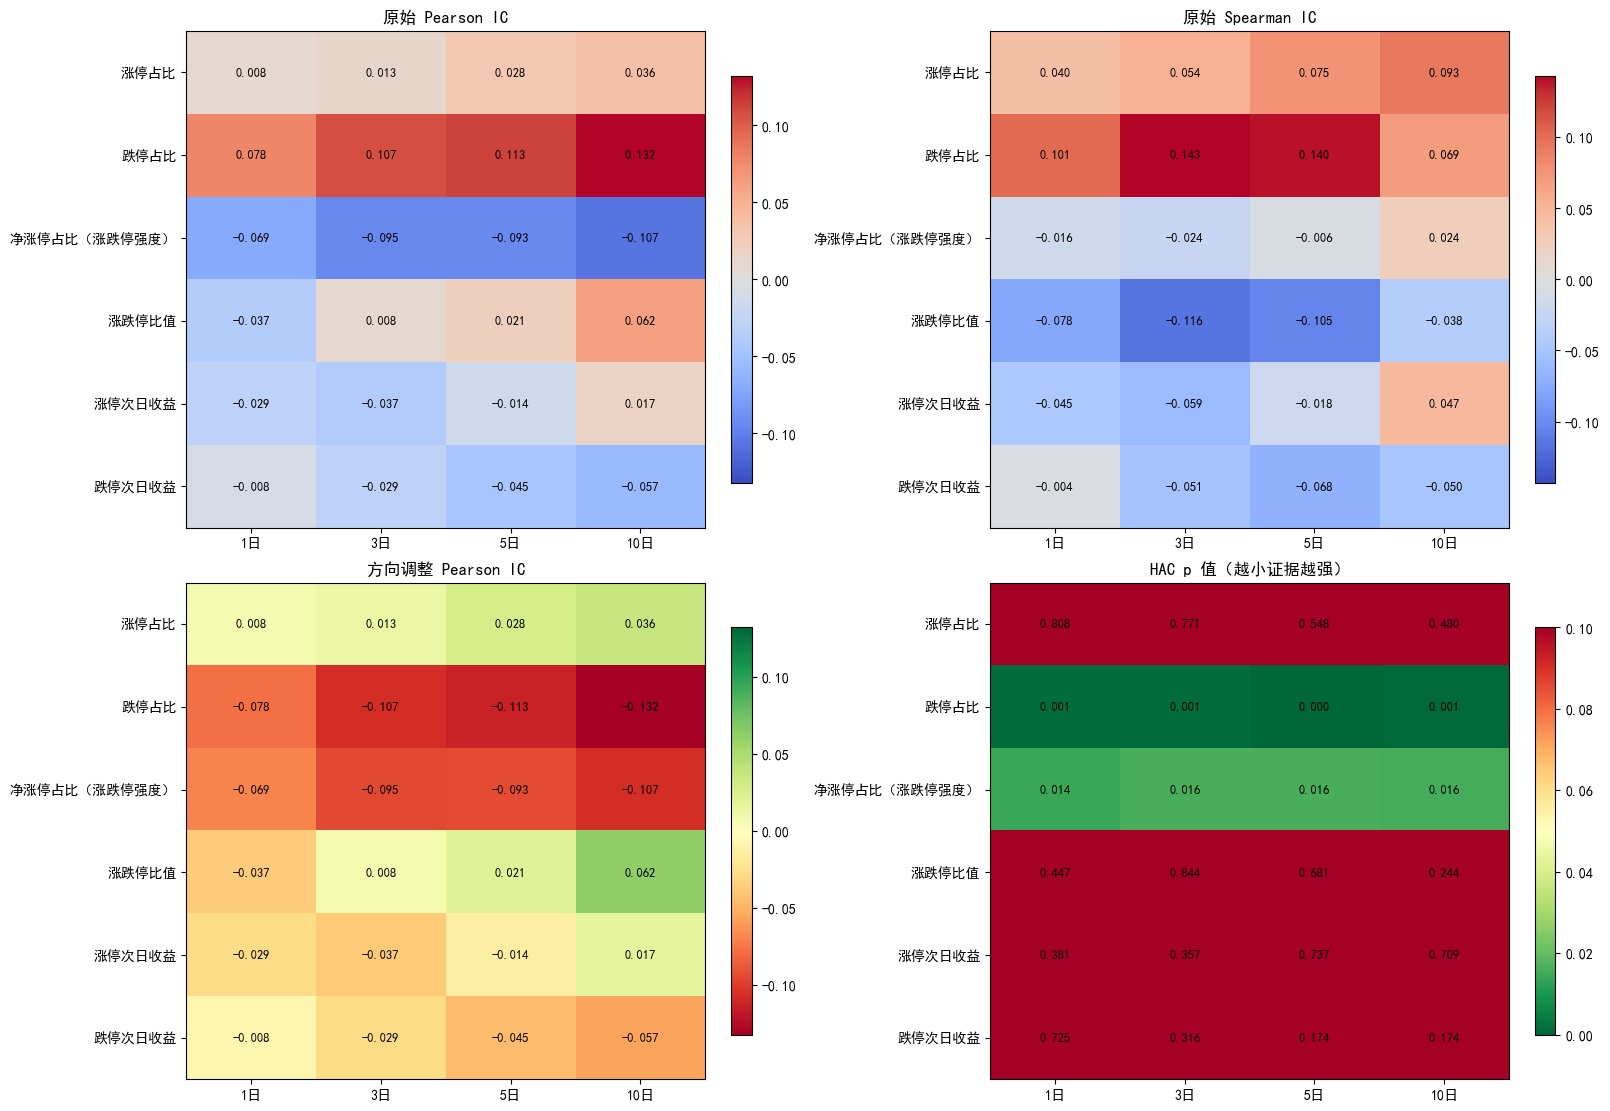

In [7]:
heatmap_specs = [
    ("pearson_ic", "原始 Pearson IC", "coolwarm", None),
    ("spearman_ic", "原始 Spearman IC", "coolwarm", None),
    ("directional_pearson_ic", "方向调整 Pearson IC", "RdYlGn", None),
    ("hac_pvalue", "HAC p 值（越小证据越强）", "RdYlGn_r", (0, 0.10)),
]
factor_order = [FACTOR_LABELS[factor] for factor in FACTOR_COLUMNS]
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)

for axis, (metric, title, cmap, fixed_range) in zip(axes.ravel(), heatmap_specs):
    matrix = (
        ic_summary.pivot(index="factor_label", columns="horizon", values=metric)
        .reindex(index=factor_order, columns=HORIZONS)
    )
    values = matrix.to_numpy(dtype=float)
    if fixed_range is None:
        limit = max(0.05, np.nanmax(np.abs(values)))
        image = axis.imshow(values, aspect="auto", cmap=cmap, vmin=-limit, vmax=limit)
    else:
        image = axis.imshow(values, aspect="auto", cmap=cmap, vmin=fixed_range[0], vmax=fixed_range[1])
    axis.set_xticks(range(len(HORIZONS)), [f"{h}日" for h in HORIZONS])
    axis.set_yticks(range(len(factor_order)), factor_order)
    axis.set_title(title)
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            label = "—" if np.isnan(value) else f"{value:.3f}"
            axis.text(column_index, row_index, label, ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=axis, shrink=0.82)

plt.show()

In [8]:
# 单独核对经验预期：跌停占比原始 IC 应为负；这里展示结果，不把经验判断硬编码成断言。
limit_down_ic_check = ic_summary.loc[
    ic_summary["factor"] == "limit_down_ratio",
    ["horizon", "pearson_ic", "spearman_ic", "hac_t", "hac_pvalue"],
].copy()
limit_down_ic_check.columns = ["未来日数", "Pearson IC", "Spearman IC", "HAC t值", "HAC p值"]
limit_down_ic_check.style.format(
    {"Pearson IC": "{:.4f}", "Spearman IC": "{:.4f}", "HAC t值": "{:.2f}", "HAC p值": "{:.4f}"}
)

,未来日数,Pearson IC,Spearman IC,HAC t值,HAC p值
4,1,0.0776,0.1010,3.24,0.0012
5,3,0.1072,0.1432,3.24,0.0012
6,5,0.1134,0.1396,3.62,0.0003
7,10,0.1321,0.0692,3.48,0.0005


## 6. 历史扩展阈值

每个交易日的阈值只由前一日及更早的因子值决定。80% 分位并不是“最优参数”，只是统一、可复现且无全样本寻优的触发标准。六项因子完成至少 252 个历史有效观测后，从首次共同可用日统一开始比较。

In [9]:
timing_input = build_expanding_thresholds(
    research_data,
    factor_columns=FACTOR_COLUMNS,
    quantile=THRESHOLD_QUANTILE,
    min_history=MIN_HISTORY,
)
common_anchor = find_common_anchor(timing_input, factor_columns=FACTOR_COLUMNS)

threshold_rows = []
for factor in FACTOR_COLUMNS:
    threshold_column = f"threshold_{factor}"
    first_valid_index = timing_input[threshold_column].first_valid_index()
    after_anchor = timing_input.loc[timing_input["trading_date"] >= common_anchor]
    if FACTOR_DIRECTIONS[factor] > 0:
        trigger = after_anchor[factor] >= after_anchor[threshold_column]
        rule = "因子 ≥ 历史80%分位时持有"
    else:
        trigger = after_anchor[factor] >= after_anchor[threshold_column]
        rule = "因子 ≥ 历史80%分位时空仓"
    threshold_rows.append(
        {
            "因子": FACTOR_LABELS[factor],
            "方向": "正向" if FACTOR_DIRECTIONS[factor] > 0 else "负向",
            "规则": rule,
            "阈值首次可用日": timing_input.loc[first_valid_index, "trading_date"].date(),
            "共同起跑后触发率": trigger.mean(),
        }
    )

threshold_overview = pd.DataFrame(threshold_rows)
print(f"六因子统一择时起点：{common_anchor.date()}")
threshold_overview.style.format({"共同起跑后触发率": "{:.2%}"})

六因子统一择时起点：2019-01-21


,因子,方向,规则,阈值首次可用日,共同起跑后触发率
0,涨停占比,正向,因子 ≥ 历史80%分位时持有,2019-01-21,14.59%
1,跌停占比,负向,因子 ≥ 历史80%分位时空仓,2019-01-21,13.20%
2,净涨停占比（涨跌停强度）,正向,因子 ≥ 历史80%分位时持有,2019-01-21,15.30%
3,涨跌停比值,正向,因子 ≥ 历史80%分位时持有,2019-01-21,23.43%
4,涨停次日收益,正向,因子 ≥ 历史80%分位时持有,2019-01-21,13.20%
5,跌停次日收益,正向,因子 ≥ 历史80%分位时持有,2019-01-21,24.81%


## 7. 单因子四周期择时

对每个 n，在统一锚点每 n 个交易日调仓一次：调仓日收盘观察因子，仓位作用于随后完整 n 日。正向因子触发阈值才持有；负向的跌停占比触发阈值则空仓，否则持有。基准始终满仓，并与策略使用完全相同的日期。

- **持仓胜率**：实际持有的 n 日区间中，基准累计收益大于 0 的比例。
- **择时命中率**：持有且上涨，或空仓且区间收益不大于 0，均视为方向判断正确。

In [10]:
timing_daily = {}
timing_blocks = {}
timing_summary_rows = []

for factor in FACTOR_COLUMNS:
    for horizon in HORIZONS:
        daily_detail, block_detail = run_non_overlapping_timing(
            timing_input,
            factor=factor,
            horizon=horizon,
            anchor_date=common_anchor,
            direction=FACTOR_DIRECTIONS[factor],
        )
        timing_daily[(factor, horizon)] = daily_detail
        timing_blocks[(factor, horizon)] = block_detail
        timing_summary_rows.append(
            summarize_timing(
                daily_detail,
                block_detail,
                factor=factor,
                horizon=horizon,
            )
        )

timing_summary = pd.DataFrame(timing_summary_rows)
timing_summary["annual_excess_return"] = (
    timing_summary["annual_return"] - timing_summary["benchmark_annual_return"]
)
assert len(timing_summary) == len(FACTOR_COLUMNS) * len(HORIZONS) == 24
assert np.isfinite(timing_summary[["final_nav", "benchmark_final_nav"]].to_numpy()).all()

timing_display = timing_summary[
    [
        "factor_label", "horizon", "rebalance_count", "holding_ratio",
        "holding_win_rate", "timing_hit_rate", "annual_return",
        "benchmark_annual_return", "annual_excess_return", "max_drawdown",
        "sharpe", "final_nav", "benchmark_final_nav", "relative_final_nav",
    ]
].rename(
    columns={
        "factor_label": "因子",
        "horizon": "持有日数",
        "rebalance_count": "调仓段数",
        "holding_ratio": "持仓比例",
        "holding_win_rate": "持仓胜率",
        "timing_hit_rate": "择时命中率",
        "annual_return": "策略年化",
        "benchmark_annual_return": "基准年化",
        "annual_excess_return": "年化差",
        "max_drawdown": "策略最大回撤",
        "sharpe": "策略夏普",
        "final_nav": "策略期末净值",
        "benchmark_final_nav": "基准期末净值",
        "relative_final_nav": "相对期末净值",
    }
)
timing_display.style.format(
    {
        "持仓比例": "{:.2%}", "持仓胜率": "{:.2%}", "择时命中率": "{:.2%}",
        "策略年化": "{:.2%}", "基准年化": "{:.2%}", "年化差": "{:+.2%}",
        "策略最大回撤": "{:.2%}", "策略夏普": "{:.2f}",
        "策略期末净值": "{:.3f}", "基准期末净值": "{:.3f}", "相对期末净值": "{:+.2%}",
    }
)

,因子,持有日数,调仓段数,持仓比例,持仓胜率,择时命中率,策略年化,基准年化,年化差,策略最大回撤,策略夏普,策略期末净值,基准期末净值,相对期末净值
0,涨停占比,1,1809,14.59%,56.82%,48.87%,4.38%,9.38%,-5.00%,-13.60%,0.48,1.360,1.904,-28.54%
1,涨停占比,3,603,13.93%,51.19%,47.76%,3.81%,9.38%,-5.57%,-14.88%,0.43,1.308,1.904,-31.29%
2,涨停占比,5,361,14.40%,57.69%,50.97%,5.51%,9.67%,-4.16%,-13.80%,0.58,1.468,1.937,-24.19%
3,涨停占比,10,180,12.78%,65.22%,49.44%,3.24%,9.85%,-6.61%,-12.34%,0.38,1.256,1.956,-35.82%
4,跌停占比,1,1809,86.84%,52.13%,50.58%,0.28%,9.38%,-9.10%,-46.96%,0.10,1.020,1.904,-46.39%
5,跌停占比,3,603,86.40%,51.63%,50.25%,3.14%,9.38%,-6.24%,-47.58%,0.27,1.249,1.904,-34.40%
6,跌停占比,5,361,87.26%,48.89%,46.81%,4.95%,9.67%,-4.72%,-40.62%,0.37,1.414,1.937,-27.01%
7,跌停占比,10,180,86.11%,52.26%,49.44%,6.75%,9.85%,-3.11%,-35.00%,0.47,1.594,1.956,-18.52%
8,净涨停占比（涨跌停强度）,1,1809,15.31%,55.23%,48.48%,1.49%,9.38%,-7.89%,-24.09%,0.20,1.112,1.904,-41.58%
9,净涨停占比（涨跌停强度）,3,603,13.60%,46.34%,46.43%,1.91%,9.38%,-7.47%,-20.86%,0.25,1.146,1.904,-39.82%


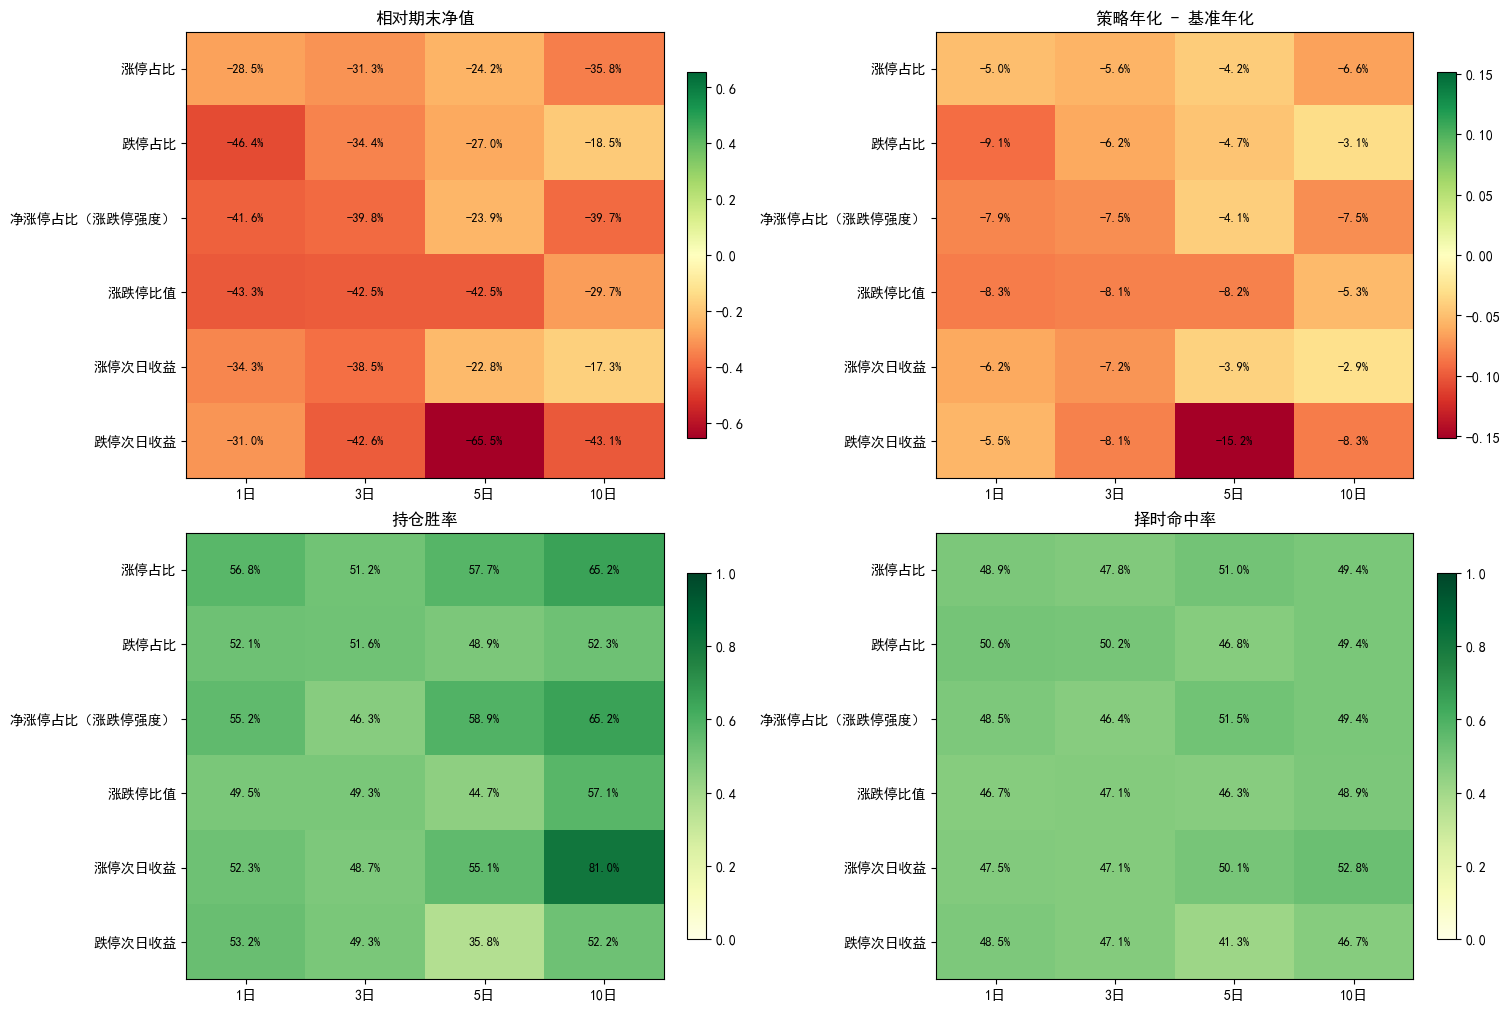

In [11]:
timing_heatmaps = [
    ("relative_final_nav", "相对期末净值", "{:+.1%}"),
    ("annual_excess_return", "策略年化 - 基准年化", "{:+.1%}"),
    ("holding_win_rate", "持仓胜率", "{:.1%}"),
    ("timing_hit_rate", "择时命中率", "{:.1%}"),
]
fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

for axis, (metric, title, number_format) in zip(axes.ravel(), timing_heatmaps):
    matrix = (
        timing_summary.pivot(index="factor_label", columns="horizon", values=metric)
        .reindex(index=factor_order, columns=HORIZONS)
    )
    values = matrix.to_numpy(dtype=float)
    if metric in ("relative_final_nav", "annual_excess_return"):
        limit = max(0.01, np.nanmax(np.abs(values)))
        image = axis.imshow(values, aspect="auto", cmap="RdYlGn", vmin=-limit, vmax=limit)
    else:
        image = axis.imshow(values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)
    axis.set_xticks(range(len(HORIZONS)), [f"{h}日" for h in HORIZONS])
    axis.set_yticks(range(len(factor_order)), factor_order)
    axis.set_title(title)
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            label = "—" if np.isnan(value) else number_format.format(value)
            axis.text(column_index, row_index, label, ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=axis, shrink=0.82)

plt.show()

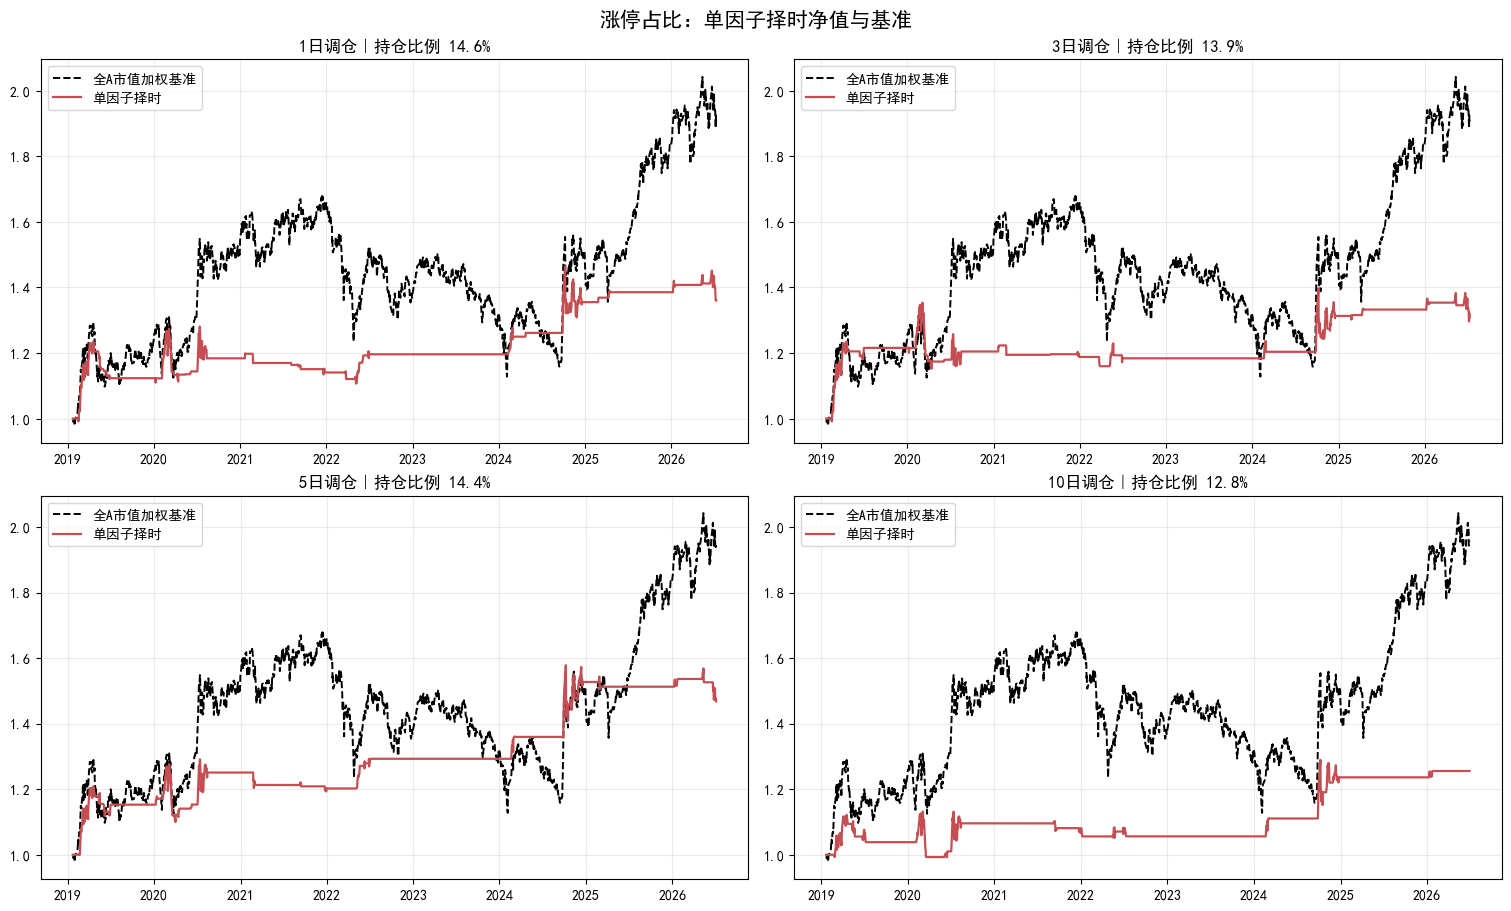

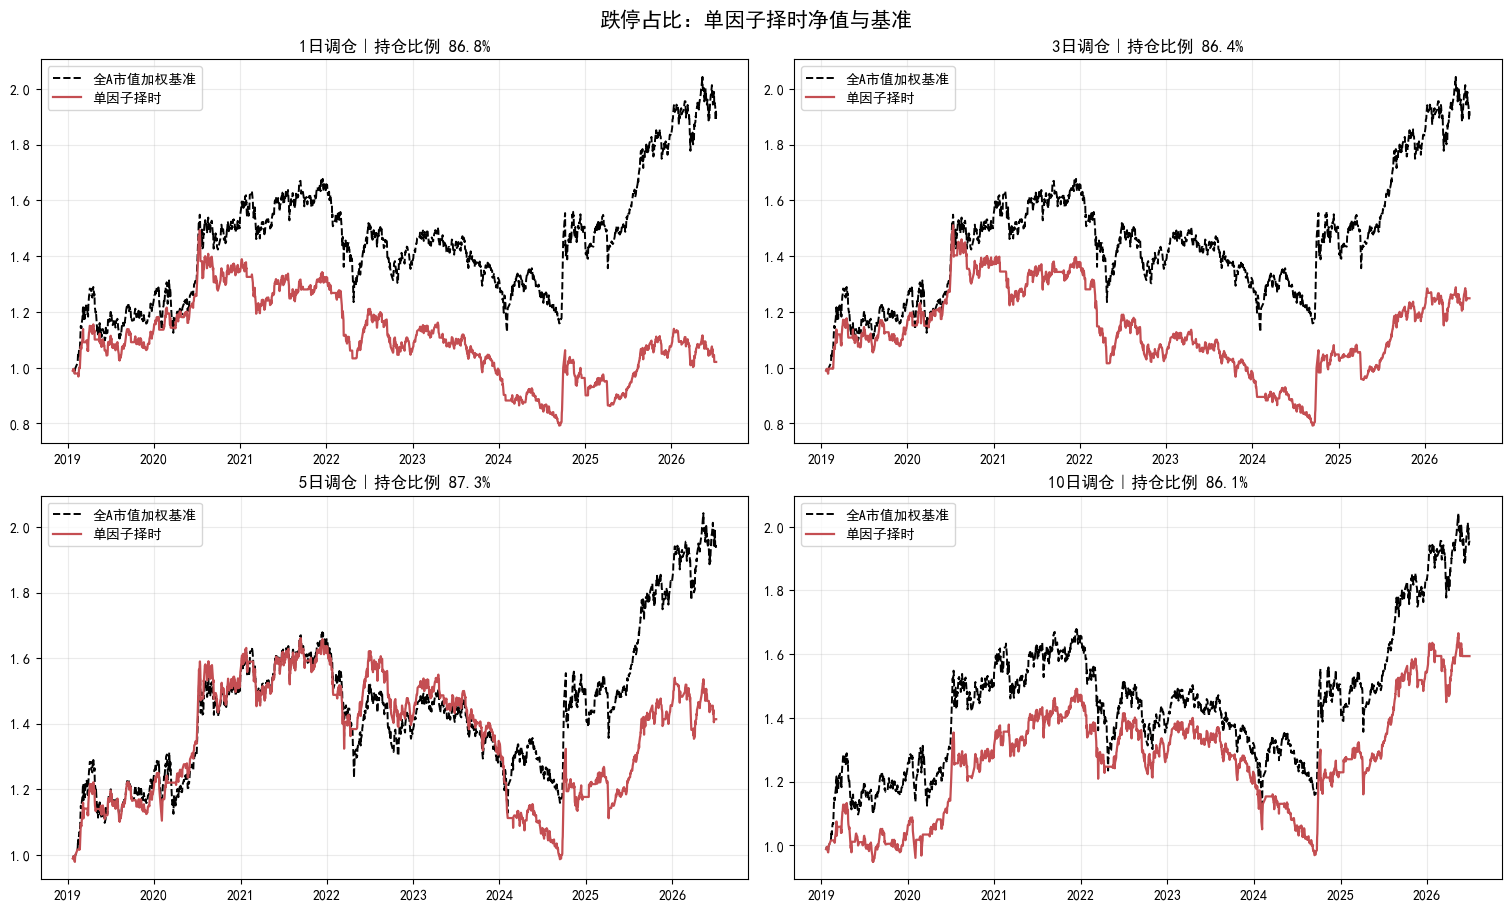

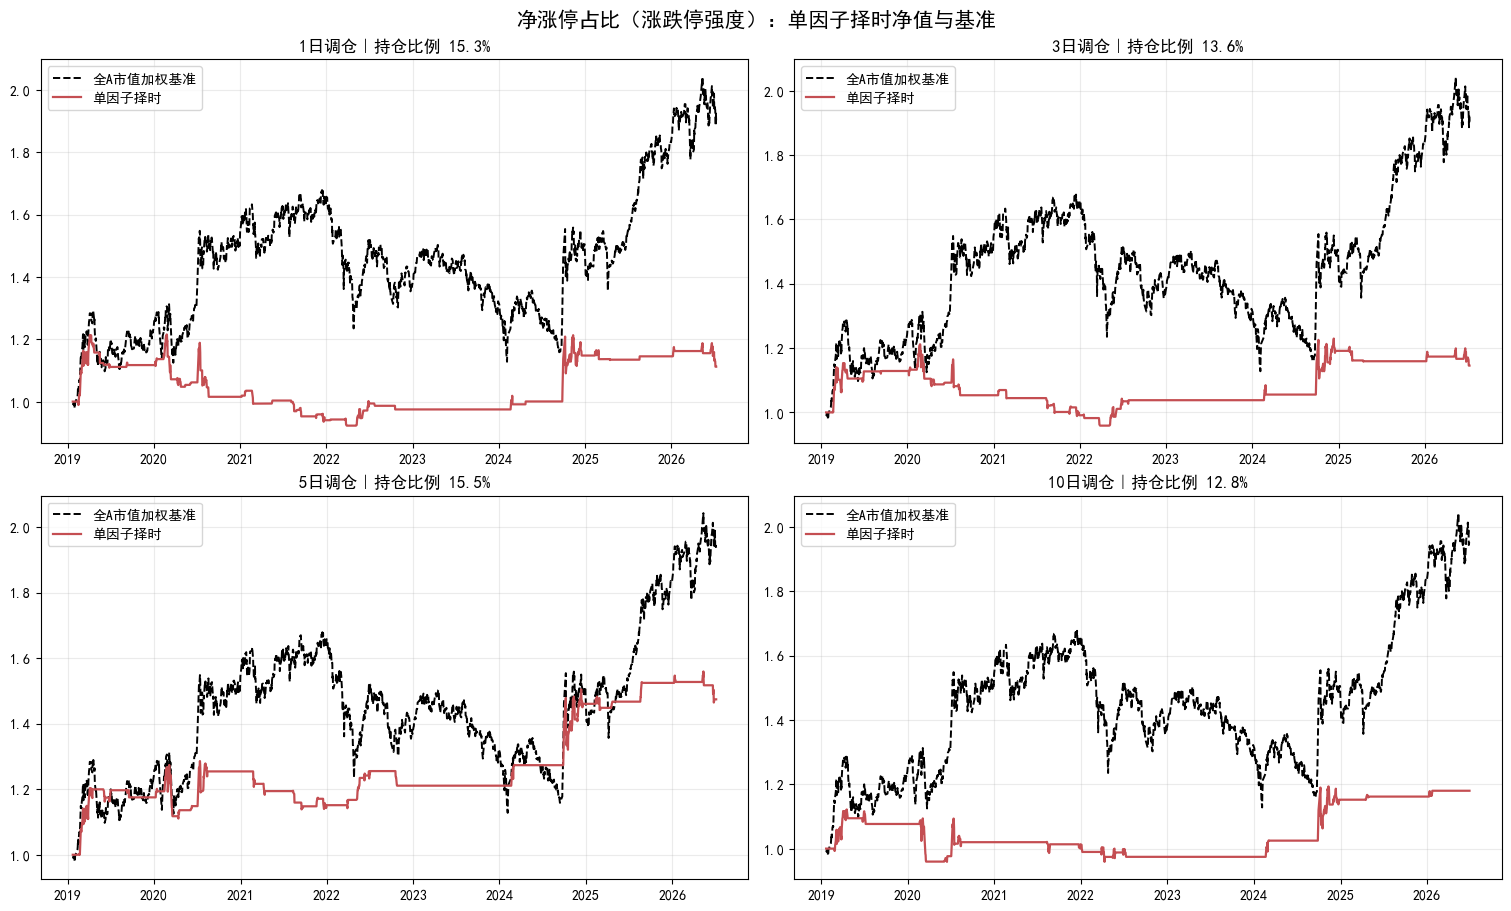

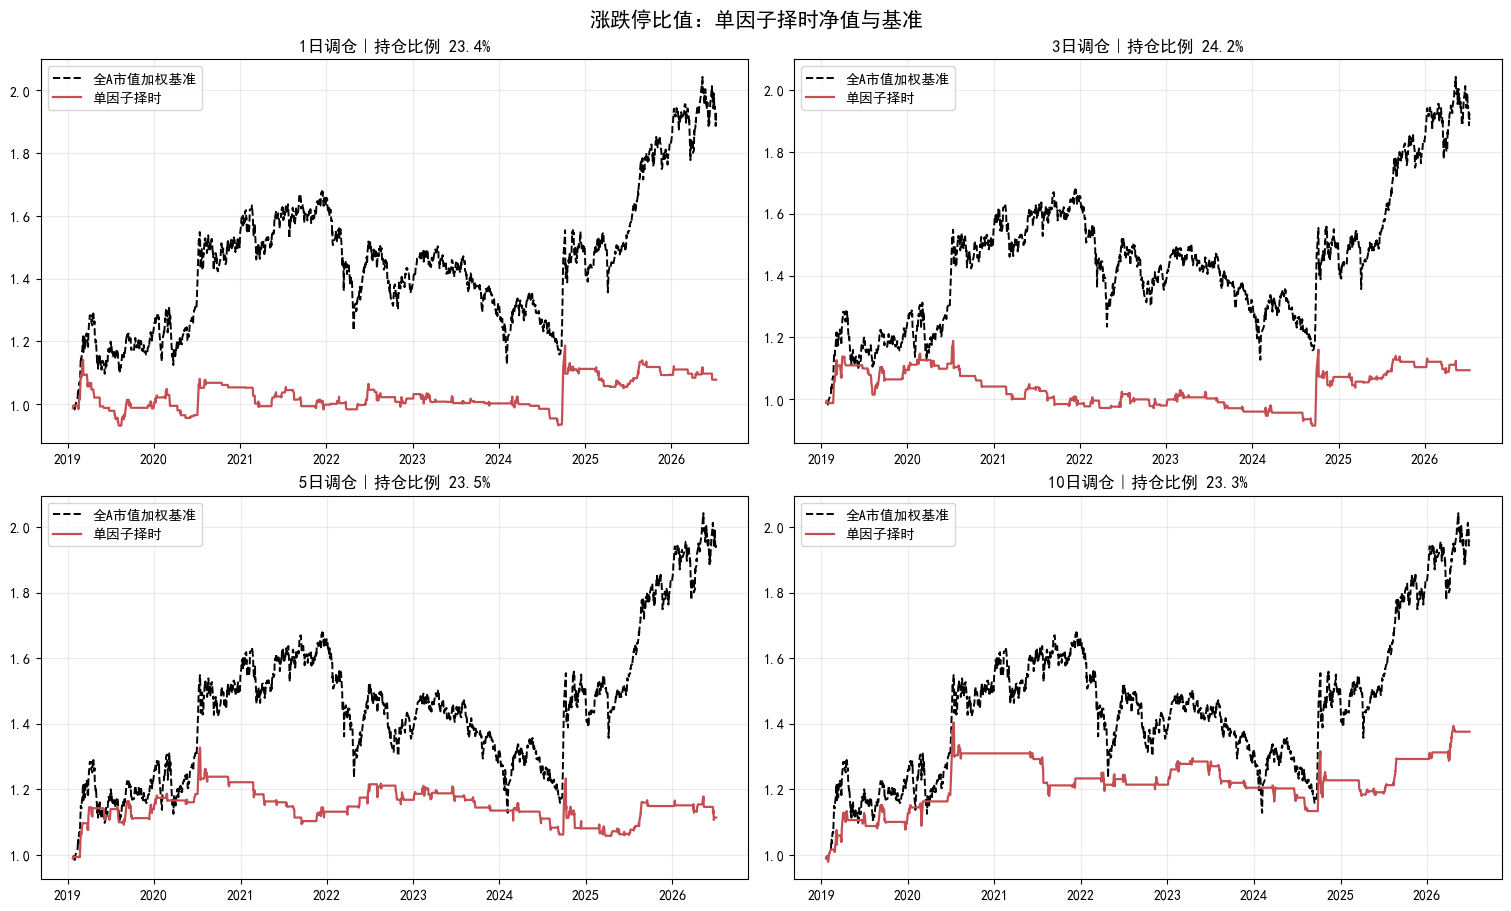

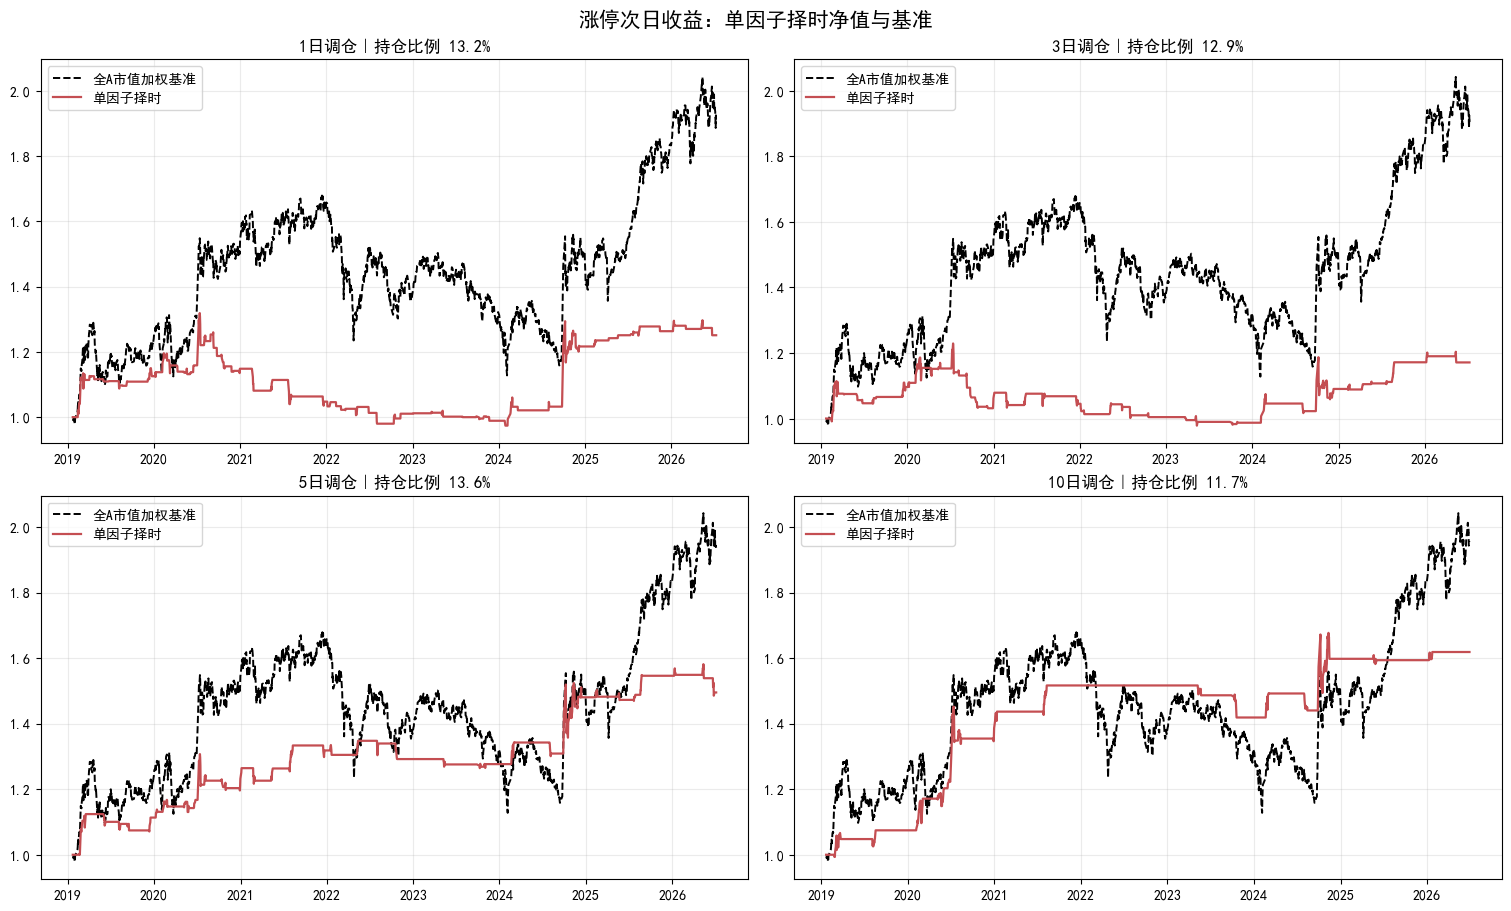

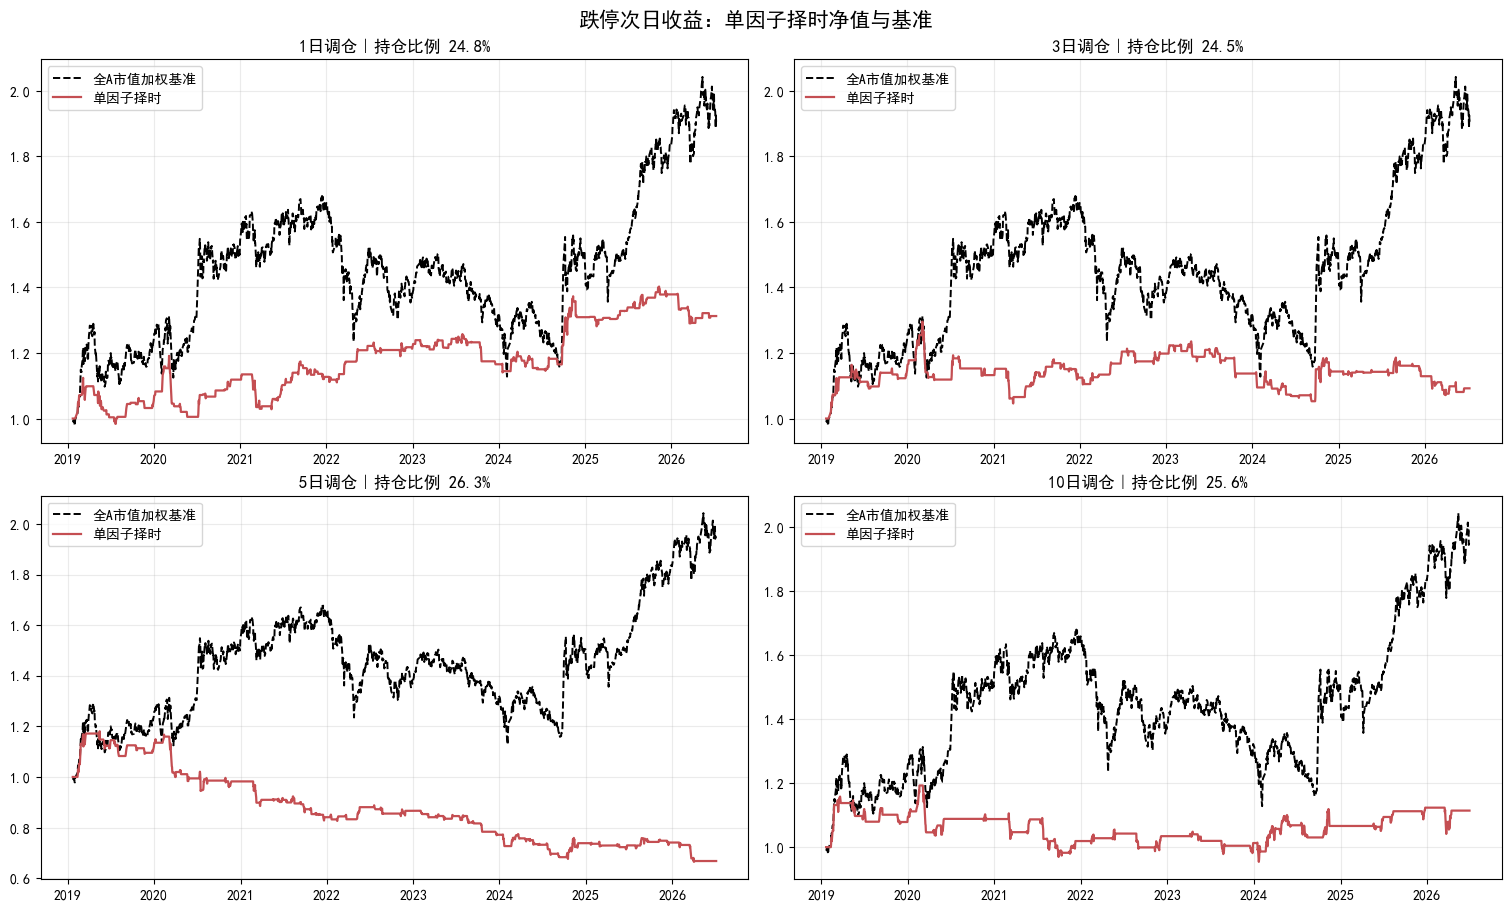

In [12]:
for factor in FACTOR_COLUMNS:
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)
    for axis, horizon in zip(axes.ravel(), HORIZONS):
        detail = timing_daily[(factor, horizon)]
        axis.plot(
            detail["trading_date"], detail["benchmark_nav"],
            label="全A市值加权基准", color="black", linestyle="--", linewidth=1.4,
        )
        axis.plot(
            detail["trading_date"], detail["strategy_nav"],
            label="单因子择时", color="#C44E52", linewidth=1.6,
        )
        exposure = detail["position"].mean()
        axis.set_title(f"{horizon}日调仓｜持仓比例 {exposure:.1%}")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle(f"{FACTOR_LABELS[factor]}：单因子择时净值与基准", fontsize=15)
    plt.show()

## 8. 结果归纳与使用边界

下面只做可复核的描述：相关方向是否跨周期一致、HAC 证据有多少个周期显著、以及四个非重叠调仓周期中有多少次跑赢同区间基准。相关性不等于可交易性；择时净值也仍是样本内、零成本结果。

In [13]:
ic_conclusion = (
    ic_summary.groupby(["factor", "factor_label"], as_index=False)
    .agg(
        平均原始IC=("pearson_ic", "mean"),
        平均方向调整IC=("directional_pearson_ic", "mean"),
        方向一致周期数=("directional_pearson_ic", lambda values: int((values > 0).sum())),
        HAC显著周期数=("hac_pvalue", lambda values: int((values < 0.05).sum())),
    )
)
timing_conclusion = (
    timing_summary.groupby(["factor", "factor_label"], as_index=False)
    .agg(
        平均年化差=("annual_excess_return", "mean"),
        平均相对期末净值=("relative_final_nav", "mean"),
        平均择时命中率=("timing_hit_rate", "mean"),
        跑赢基准周期数=("relative_final_nav", lambda values: int((values > 0).sum())),
    )
)
conclusion_table = ic_conclusion.merge(
    timing_conclusion,
    on=["factor", "factor_label"],
    how="left",
).rename(columns={"factor_label": "因子"})

limit_down_rows = ic_summary[ic_summary["factor"] == "limit_down_ratio"].sort_values("horizon")
negative_horizons = limit_down_rows.loc[limit_down_rows["pearson_ic"] < 0, "horizon"].tolist()
best_ic_row = conclusion_table.loc[conclusion_table["平均方向调整IC"].idxmax()]
best_timing_row = conclusion_table.loc[conclusion_table["平均相对期末净值"].idxmax()]

print(
    f"跌停占比在 {len(negative_horizons)}/4 个周期呈负 Pearson IC："
    f"{negative_horizons if negative_horizons else '无'}。"
)
print(
    f"方向调整后平均 IC 最高的是“{best_ic_row['因子']}”"
    f"（{best_ic_row['平均方向调整IC']:.4f}）。"
)
print(
    f"四周期平均相对期末净值最高的是“{best_timing_row['因子']}”"
    f"（{best_timing_row['平均相对期末净值']:+.2%}）。"
)
outperform_total = int((timing_summary["relative_final_nav"] > 0).sum())
print(f"全部 24 组单因子择时中，共有 {outperform_total} 组跑赢同期满仓基准。")

conclusion_table[
    [
        "因子", "平均原始IC", "平均方向调整IC", "方向一致周期数", "HAC显著周期数",
        "平均年化差", "平均相对期末净值", "平均择时命中率", "跑赢基准周期数",
    ]
].style.format(
    {
        "平均原始IC": "{:.4f}", "平均方向调整IC": "{:.4f}",
        "平均年化差": "{:+.2%}", "平均相对期末净值": "{:+.2%}",
        "平均择时命中率": "{:.2%}",
    }
)

跌停占比在 0/4 个周期呈负 Pearson IC：无。
方向调整后平均 IC 最高的是“涨停占比”（0.0212）。
四周期平均相对期末净值最高的是“涨停次日收益”（-28.20%）。
全部 24 组单因子择时中，共有 0 组跑赢同期满仓基准。


,因子,平均原始IC,平均方向调整IC,方向一致周期数,HAC显著周期数,平均年化差,平均相对期末净值,平均择时命中率,跑赢基准周期数
0,跌停次日收益,-0.0346,-0.0346,0,0,-9.29%,-45.56%,45.88%,0
1,跌停占比,0.1076,-0.1076,0,4,-5.79%,-31.58%,49.27%,0
2,涨跌停比值,0.0135,0.0135,3,0,-7.47%,-39.51%,47.23%,0
3,涨停次日收益,-0.0156,-0.0156,1,0,-5.03%,-28.20%,49.37%,0
4,涨停占比,0.0212,0.0212,4,0,-5.34%,-29.96%,49.26%,0
5,净涨停占比（涨跌停强度）,-0.0909,-0.0909,0,4,-6.74%,-36.24%,48.97%,0


### 阅读结论时保留的限制

1. 数据从 2018 年开始，结论仅代表当前本地样本，不等同于研报更长历史的完整复现。
2. 因子使用沪深 A 股收盘封板事件；基准是本地前一日市值加权代理，不是 Wind 全 A。
3. 80% 分位阈值没有做样本内最优化，但仍应通过滚动样本外或不同市场阶段继续验证。
4. 回测不含交易成本、滑点和指数复制误差；本轮目标只是判断六个指标是否值得继续研究。